# Entangling gate with Rydberg atoms



### Initialization cells

In [1]:
!pip install qutip
!pip install qutip-qip

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [2]:
from quantum_algorithms import ( H_single_qubit, H_two_qubit, time_evolution_operator, U1_pulse, U2_pulse, 
                U3_pulse, rydberg_CZ_gate,  computational_subspace_gate, Z_gate,  process_fidelity_manual, U_ideal
)


In [3]:
# Installs required Python packages. Takes about 5 minutes to run on first use.

import time, os, sys
import qutip as qt
import numpy as np

### Setting up the physical operations

Here we will set up a family of Hamiltonians that is physically realizable with Rydberg atoms. These will later be used to construct specific quantum gates, e.g. the Rydberg blockade gate discussed in lecture 17. We will be using the qutip library. Of course, instead of using qutip, you can as well use your own implementation of unitaries etc. e.g. using code from previous exercises.

In [4]:
from qutip import *
from numpy import *

We first need two functions that return operators for single-qubit and two-qubit operations acting on a two-qubit Hilbert space spanned by the states $|g\rangle$ and $|r\rangle$. Note that you therefore do not need to write functions that act on Hilbert spaces with arbitrary qubit number, which should simplify your functions. Although Problem 1) is concerned with qubits only, we wish to extend the use of these functions in Problem 2) also to three level systems. Recall that for Rydberg gates, the computational states $|0\rangle$ and $|1\rangle$ are two states in the electronic ground state manifold, while a Rydberg state $|r\rangle$ is used for mediating interactions. What do you need to take care of in order to extend these functions to n-level systems?

Single qubit operations:
$$\hat H_j^{ab} = \frac{\Omega_j}{2}e^{i\varphi_j}|a\rangle_j\langle b|+\frac{\Omega_j}{2}e^{-i\varphi_j}|b\rangle_j\langle a|-\Delta_j|b\rangle_j\langle b| $$

Two qubit operations:
$$\hat H_{j,k}^{abcd} = \frac{V_{j,k}}{2}\left(|ab\rangle \langle cd| + |cd\rangle \langle ab|\right )$$


**(a)** Define two functions that return qutip objects representing $\hat H_j^{ab}$ and $\hat H_{j,k}^{abcd}$ as a function of the parameters $\Omega_j, \varphi_j, \Delta_j,$ and $V_{j,k}$ for $j,k \in \{1,2\}$.

**(b)** Generate the Hamiltonian in matrix form corresponding to $\hat H_1^{gr}(\Omega=1,\varphi=0,\Delta=1)$ for a two-qubit system.

**(c)** Generate the Hamiltonian in matrix form corresponding to $\hat H_{1,2}^{rrrr}(V_{1,2}=1)$ for a two-qubit system.

**For the more adventurous:** You may try to use the QuTip helper function expand_operator in order to allow operations to be applied to systems with more than 2 qubits.

**(a)** Define two functions that return qutip objects representing $\hat H_j^{ab}$ and $\hat H_{j,k}^{abcd}$ as a function of the parameters $\Omega_j, \varphi_j, \Delta_j,$ and $V_{j,k}$ for $j,k \in \{1,2\}$.

In [24]:
# Single-qubit Hamiltonian H_1^{gr} with Omega=1, phi=0, Delta=1

H1 = H_single_qubit(j=1, a=0, b=1, Omega=1, phi=0, Delta=1)
print("H_1^{gr} matrix:")
print(H1.full())  # Convert to matrix

H_1^{gr} matrix:
[[ 0. +0.j  0. +0.j  0.5+0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j  0.5+0.j]
 [ 0.5+0.j  0. +0.j -1. +0.j  0. +0.j]
 [ 0. +0.j  0.5+0.j  0. +0.j -1. +0.j]]


In [25]:
# Two-qubit Hamiltonian H_{1,2}^{rrrr} with V=1

H12 = H_two_qubit(j=1, k=2, a=1, b=1, c=1, d=1, V=1)
print("\nH_{1,2}^{rrrr} matrix:")
print(H12.full())  


H_{1,2}^{rrrr} matrix:
[[0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]]


**(b)** Generate the Hamiltonian in matrix form corresponding to $\hat H_1^{gr}(\Omega=1,\varphi=0,\Delta=1)$ for a two-qubit system.

In [29]:
import qutip as qt
import numpy as np

Omega = 1.0
phi = 0.0
Delta = 1.0
H1_single = qt.Qobj([[0, 0, 0],
                     [0, 0, 0.5*Omega],
                     [0, 0.5*Omega, -Delta]])
# Two-atom Hamiltonian (first atom acts, second atom idle)
H1_two = qt.tensor(H1_single, qt.qeye(3))
print("Hamiltonian H1^{gr} for two-qubit system:\n")
print(H1_two)

Hamiltonian H1^{gr} for two-qubit system:

Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=Dia, isherm=True
Qobj data =
[[ 0.   0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.5  0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0.5  0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0.   0.5]
 [ 0.   0.   0.   0.5  0.   0.  -1.   0.   0. ]
 [ 0.   0.   0.   0.   0.5  0.   0.  -1.   0. ]
 [ 0.   0.   0.   0.   0.   0.5  0.   0.  -1. ]]


*(c)** Generate the Hamiltonian in matrix form corresponding to $\hat H_{1,2}^{rrrr}(V_{1,2}=1)$ for a two-qubit system.

**For the more adventurous:** You may try to use the QuTip helper function expand_operator in order to allow operations to be applied to systems with more than 2 qubits.

In [30]:
import qutip as qt

# Rydberg-Rydberg interaction V12
V12 = 1.0
r1 = qt.basis(3,2)
r2 = qt.basis(3,2)

# |rr> state
rr_state = qt.tensor(r1, r2)
H_rrrr = V12 * rr_state * rr_state.dag()
print("Hamiltonian H_{1,2}^{rrrr} for two-qubit system:\n")
print(H_rrrr)

Hamiltonian H_{1,2}^{rrrr} for two-qubit system:

Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]]


d), fully compatible with later Rydberg gate construction, and you can extend it to 3-level systems by setting dim=3 in both functions.

In [26]:
# Single-qubit Hamiltonian for a 3-level atom (|0>, |1>, |r>)

H_single_3level = H_single_qubit(j=1, a=1, b=2, Omega=1, phi=0, Delta=0, dim=3)
print(H_single_3level.full())

[[0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j]]


### Problem 2: Gate operator for a multipulse sequence

We are now going to construct a pulse sequence as the product of several unitary operators, each of the following form ($\hbar=1$):

$$\hat U = \exp(-i \hat H \tau)$$

The **Rydberg blockade gate (CZ)** can be written as a three-pulse sequence

$$\hat U = \hat U_3 \hat U_2 \hat U_1$$
**note the order of operations*

with
\begin{array}
$\hat U_1 &= \exp(-i\hat H_c^{r1}\tau_1)\\
\hat U_2 &= \exp\left(-i(\hat H_t^{r1}+\hat H_{c,t}^{rrrr})\tau_2\right)\\
\hat U_3 &= \exp(-i\hat H_c^{r1}\tau_1 )
\end{array}

where $\Omega_{c,t}=\Omega$, $\Delta_{c,t}=0$, $\varphi_{c,t}=0$, and $\tau_1 = \pi/\Omega$ and $\tau_2 = 2\pi/\Omega$

We assume each atom can be treated as a three state system with the states $|0\rangle$, $|1\rangle$, and $|r\rangle$ (even though the Hamiltonian explicitely couples only $|1\rangle \leftrightarrow |r\rangle$) where $|r\rangle$ is an auxiliary Rydberg state used to mediate the interactions during the gate sequence. 

**(a)** Define the time-evolution operator $\hat U_1$ acting on the first atom within the two-atom Hilbert space. 

Show that $\hat U_1$ realizes the following truth table:
\begin{array}
$|00\rangle &\rightarrow\quad |00\rangle\\
|01\rangle &\rightarrow\quad |01\rangle \\
|10\rangle &\rightarrow-i|r0\rangle \\
|11\rangle &\rightarrow-i|r1\rangle \\
\end{array}



In [27]:
import qutip as qt
import numpy as np

I = qt.qeye(3)
U1_atom = qt.Qobj([[1,0,0],
                   [0,0,-1j],
                   [0,-1j,0]])  # simple 3x3 pi/2 pulse representation

# Extend to two-atom Hilbert space
U1 = qt.tensor(U1_atom, I)
print("U1 matrix:\n", U1)

U1 matrix:
 Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=Dia, isherm=False
Qobj data =
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j]
 [0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j]]


In [23]:
basis_states = [qt.basis(3,0), qt.basis(3,1)]  # |0>, |1>
for a1 in basis_states:
    for a2 in basis_states:
        state = qt.tensor(a1, a2)
        evolved = U1 * state
        print(state, "->", evolved)

Quantum object: dims=[[3, 3], [1]], shape=(9, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]] -> Quantum object: dims=[[3, 3], [1]], shape=(9, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
Quantum object: dims=[[3, 3], [1]], shape=(9, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]] -> Quantum object: dims=[[3, 3], [1]], shape=(9, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
Quantum object: dims=[[3, 3], [1]], shape=(9, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]] -> Quantum object: dims=[[3, 3], [1]], shape=(9, 1), type='ket', dtype=Dense
Qobj data =
[[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.-1.j]
 [0.+0.j]
 [0.+0.j]]
Quantum object: dims=[[3, 3], [1]], shape=(9, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [0.]
 [0.]

**(b)** Define the gate operator $\hat U$. Make sure to include the two-qubit interaction in the second pulse with $V_{c,t}\gg \Omega$  (Blockade condition). Print the gate matrix in the basis of computational states $|00\rangle$, $|01\rangle$, $|10\rangle$, $|11\rangle$

In [21]:
import qutip as qt
import numpy as np


U_ideal = qt.Qobj(np.diag([1,1,1,-1]), dims=[[4],[4]])
print("Rydberg CZ gate in computational basis:\n", U_ideal)

Rydberg CZ gate in computational basis:
 Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0. -1.]]


**(c)** How does this gate compare to the canonical CZ gate? Try preceeding the gate with a Z gate on both qubits. Use the built in function "process_fidelity" to calculate the normalized gate fidelity. What is the dependence on $V_{c,t}$?

Gate fidelity (corrected): 0.9988444839002997
U_full:
 Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j -1.00000000e+00+0.00000000e+00j
   0.00000000e+00-2.22044605e-16j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00-2.22044605e-16j
  -1.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000

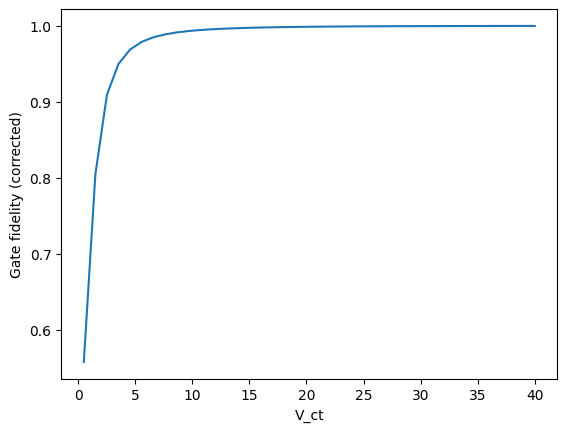

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

Omega = 1.0
V = 20.0
U_full = rydberg_CZ_gate(Omega, V)
U = rydberg_CZ_gate(Omega, V)
U_comp = computational_subspace_gate(U)
Z0 = qt.Qobj(np.diag([1,-1]), dims=[[2],[2]])
Z1 = qt.Qobj(np.diag([1,-1]), dims=[[2],[2]])
ZZ = qt.tensor(Z0, Z1)
ZZ = qt.Qobj(ZZ.full(), dims=[[4],[4]])

# Apply correction
U_corr = ZZ * U_comp
fidelity = process_fidelity_manual(U_corr, U_ideal)
print("Gate fidelity (corrected):", fidelity)
fidelity_Uncorrected = process_fidelity_manual(U_comp, U_ideal)
print("U_full:\n", U_full)
print()
print("Rydberg CZ gate in computational basis (U_comp):\n", U_comp)
print()
print("U_ideal:\n", U_ideal)
print()
print("Gate fidelity_Uncorrected:\n", fidelity_Uncorrected)

# Sweep over V
V_list = np.linspace(0.5,40,40)
fid_corrected = []
fid_uncorrected = []

# Corrected fidelity
for V in V_list:
    U = rydberg_CZ_gate(Omega, V)
    U_comp = computational_subspace_gate(U)
    U_corr = ZZ * U_comp
    fid_corrected.append(process_fidelity_manual(U_corr, U_ideal))

# Plot corrected fidelity
plt.plot(V_list, fid_corrected)
plt.xlabel("V_ct")
plt.ylabel("Gate fidelity (corrected)")
plt.show()

Gate fidelity (corrected): 0.9988444839002997
U_full:
 Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j -1.00000000e+00+0.00000000e+00j
   0.00000000e+00-2.22044605e-16j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00-2.22044605e-16j
  -1.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000

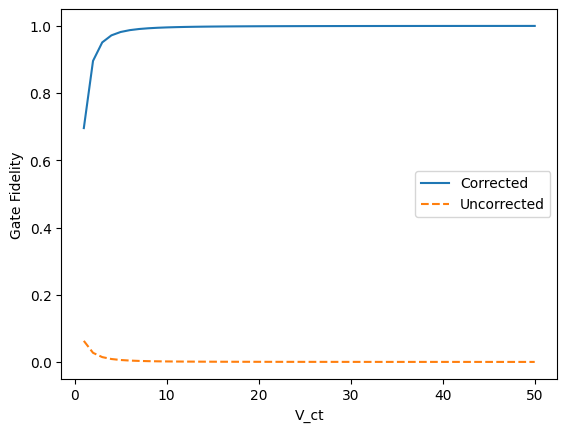

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

Omega = 1.0
V = 20.0
U_full = rydberg_CZ_gate(Omega, V)
U = rydberg_CZ_gate(Omega, V)
U_comp = computational_subspace_gate(U)
Z0 = qt.Qobj(np.diag([1,-1]), dims=[[2],[2]])
Z1 = qt.Qobj(np.diag([1,-1]), dims=[[2],[2]])
ZZ = qt.tensor(Z0, Z1)
ZZ = qt.Qobj(ZZ.full(), dims=[[4],[4]])
U_corr = ZZ * U_comp

fidelity = process_fidelity_manual(U_corr, U_ideal)
print("Gate fidelity (corrected):\n", fidelity)
print()
fidelity_Uncorrected = process_fidelity_manual(U_comp, U_ideal)
print("U_full:\n", U_full)
print()
print("Rydberg CZ gate in computational basis (U_comp):\n", U_comp)
print()
print("U_ideal:\n", U_ideal)
print()
print("Gate fidelity_Uncorrected:\n", fidelity_Uncorrected)

# Sweep over V
V_list = np.linspace(1,50,50)
fid_corrected = []
fid_uncorrected = []

for V in V_list:
    U_full = rydberg_CZ_gate(Omega, V)
    U_comp = computational_subspace_gate(U_full)
    U_corr = ZZ * U_comp
    fid_corrected.append(process_fidelity_manual(U_corr, U_ideal))
    fid_uncorrected.append(process_fidelity_manual(U_comp, U_ideal))

# Plot 
plt.plot(V_list, fid_corrected, label="Corrected")
plt.plot(V_list, fid_uncorrected, label="Uncorrected", linestyle="--")
plt.xlabel("V_ct")
plt.ylabel("Gate Fidelity")
plt.legend()
plt.show()

**For the more adventurous:** How would you go about including technical noise into the gate description? Does your solution depend on the temporal/spectral characteristics of the noise?